# Entrenamiento de modelos de regresión no lineal: Random Forest vs XGBoost
### Predicción de `PUNTAJE` a partir del estado del tablero y la carta jugada

Este notebook sigue 5 secciones:

1. Análisis exploratorio de datos (EDA)
2. Preprocesamiento de los datos
3. Entrenamiento de los modelos (Random Forest y XGBoost)
4. Comparación de métricas para escoger el mejor modelo
5. Tuning del modelo ganador

Se incorporan los puntos detectados en el análisis previo:
- Validación de las reglas del juego (suma de carta = 8, 4 posiciones no-cero).
- **Split estratificado por `RONDA`** para no sobrerrepresentar partidas cortas (ronda 1-2) frente a partidas largas (ronda 4-5).
- Chequeo de **multicolinealidad** entre las variables `T*` del tablero (no se eliminan variables porque los modelos de árboles son robustos a esto, pero se documenta para la interpretación de importancias).
- Revisión de la distribución atípica de `C2B` frente al resto de posiciones de carta.
- Verificación de cuánta varianza de `PUNTAJE` es explicable por las variables de entrada (posible componente determinístico de la fórmula de puntaje).


In [36]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_validate, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [37]:
# Carga de datos
# Ajustar la ruta si el archivo se encuentra en otra ubicación
DATA_PATH = "dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()


Shape: (2907, 21)


,C1A,C1B,C1C,C2A,C2B,C2C,C3A,C3B,C3C,T1A,...,T1C,T2A,T2B,T2C,T3A,T3B,T3C,RONDA,TURNO,PUNTAJE
0,0,0,1,0,0,2,0,4,1,0,...,0,0,0,0,0,0,0,1,1,24
1,0,0,4,1,0,0,2,1,0,0,...,-1,0,0,-2,0,-4,-1,1,2,14
2,1,0,1,0,3,0,0,3,0,0,...,-1,0,0,-2,0,-4,-1,1,2,11
3,2,0,0,1,0,3,2,0,0,0,...,-1,0,0,-2,0,-4,-1,1,2,14
4,1,4,0,2,0,0,1,0,0,0,...,-1,0,0,-2,0,-4,-1,1,2,12


## 1. Análisis exploratorio de datos (EDA)


### 1.1 Estructura general, tipos de datos, faltantes y duplicados

In [38]:
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores faltantes totales:", df.isna().sum().sum())
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
df.describe().T


Tipos de datos:
C1A        int64
C1B        int64
C1C        int64
C2A        int64
C2B        int64
C2C        int64
C3A        int64
C3B        int64
C3C        int64
T1A        int64
T1B        int64
T1C        int64
T2A        int64
T2B        int64
T2C        int64
T3A        int64
T3B        int64
T3C        int64
RONDA      int64
TURNO      int64
PUNTAJE    int64
dtype: object

Valores faltantes totales: 0
Filas duplicadas (todas las columnas): 0


,count,mean,std,min,25%,50%,75%,max
C1A,2907.0,0.640179,0.942903,0.0,0.0,0.0,1.0,4.0
C1B,2907.0,0.974544,1.177344,0.0,0.0,0.0,2.0,4.0
C1C,2907.0,0.568627,0.889848,0.0,0.0,0.0,1.0,4.0
C2A,2907.0,0.949432,1.174922,0.0,0.0,0.0,2.0,4.0
C2B,2907.0,1.750946,1.507915,0.0,0.0,3.0,3.0,4.0
C2C,2907.0,0.964912,1.171234,0.0,0.0,0.0,2.0,4.0
C3A,2907.0,0.582731,0.902481,0.0,0.0,0.0,1.0,4.0
C3B,2907.0,0.951840,1.154192,0.0,0.0,0.0,2.0,4.0
C3C,2907.0,0.616787,0.921768,0.0,0.0,0.0,1.0,4.0
T1A,2907.0,-0.392501,1.359775,-4.0,-1.0,0.0,0.0,3.0


### 1.2 Validación de las reglas del juego

Se valida que las variables de carta (`C1A...C3C`) cumplan las reglas descritas:
- La suma de las 9 posiciones de carta debe ser siempre 8.
- Exactamente 4 posiciones deben tener valores distintos de 0 (con valores del 1 al 4).


In [39]:
card_cols = ["C1A","C1B","C1C","C2A","C2B","C2C","C3A","C3B","C3C"]

card_sum = df[card_cols].sum(axis=1)
n_nonzero = (df[card_cols] != 0).sum(axis=1)

print("Filas con suma de carta != 8:", (card_sum != 8).sum())
print("Filas con cantidad de posiciones no-cero != 4:", (n_nonzero != 4).sum())


Filas con suma de carta != 8: 0
Filas con cantidad de posiciones no-cero != 4: 0


### 1.3 Distribución de `RONDA` y `TURNO`

`RONDA` está desbalanceada: las rondas avanzadas (4 y 5) tienen muchas menos muestras
que las rondas iniciales. Esto se tendrá en cuenta en el preprocesamiento con un split
estratificado.


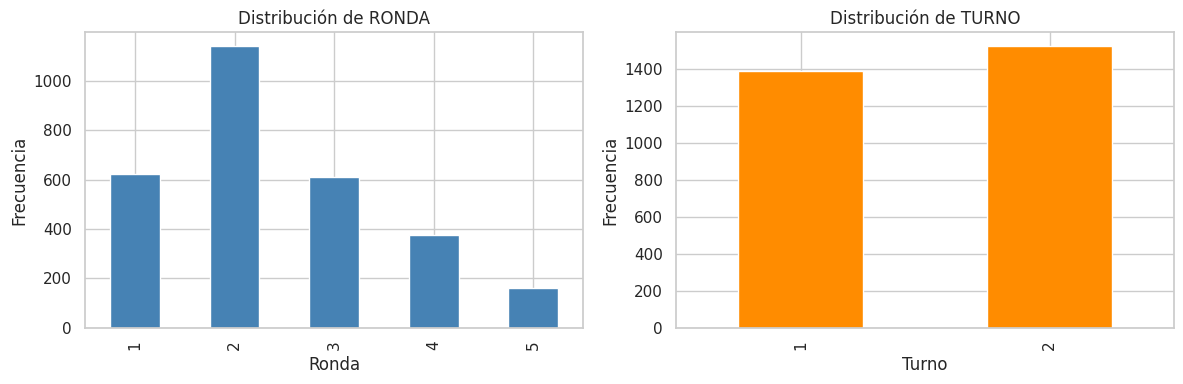

TURNO    1    2
RONDA          
1       13  611
2      691  450
3      352  257
4      210  164
5      120   39


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["RONDA"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de RONDA")
axes[0].set_xlabel("Ronda")
axes[0].set_ylabel("Frecuencia")

df["TURNO"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de TURNO")
axes[1].set_xlabel("Turno")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(pd.crosstab(df["RONDA"], df["TURNO"]))


### 1.4 Distribución de la variable objetivo `PUNTAJE`

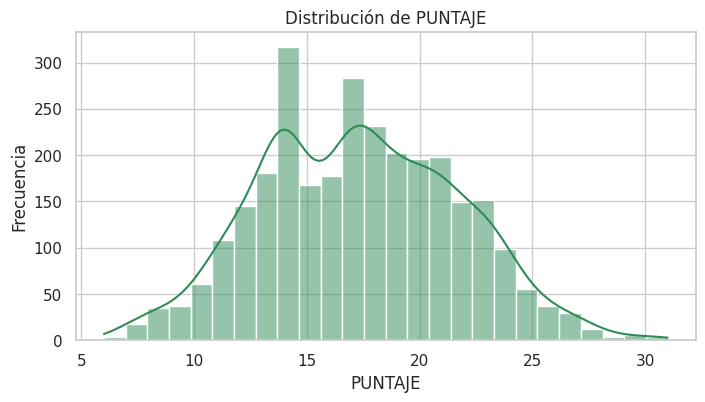

count    2907.000000
mean       17.314757
std         4.438344
min         6.000000
25%        14.000000
50%        17.000000
75%        21.000000
max        31.000000
Name: PUNTAJE, dtype: float64


In [41]:
plt.figure(figsize=(8, 4))
sns.histplot(df["PUNTAJE"], bins=26, kde=True, color="seagreen")
plt.title("Distribución de PUNTAJE")
plt.xlabel("PUNTAJE")
plt.ylabel("Frecuencia")
plt.show()

print(df["PUNTAJE"].describe())


### 1.5 Distribución de las posiciones de carta

Se revisa en particular `C2B`, que en el análisis previo mostró una distribución distinta
al resto de posiciones (más frecuencia de valor 3, menos ceros).


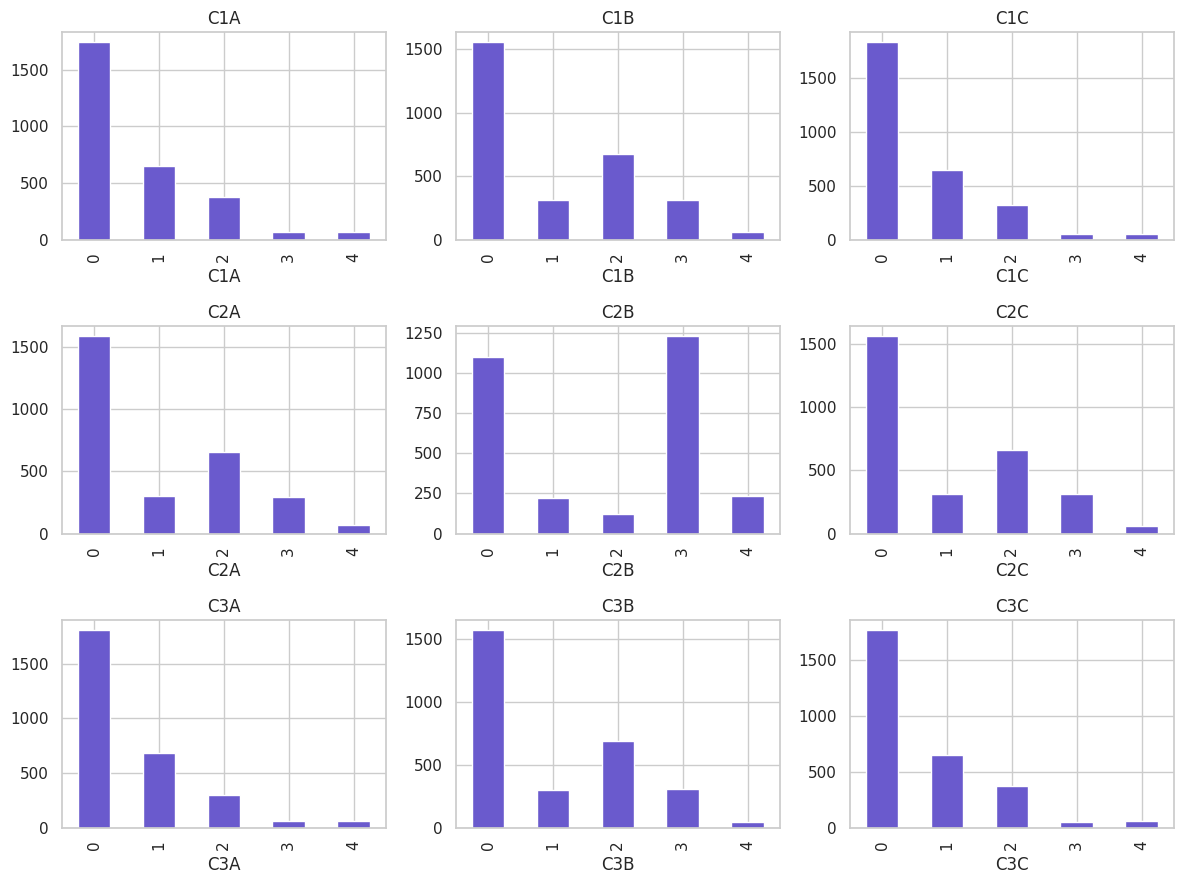

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, col in zip(axes.ravel(), card_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="slateblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 1.6 Multicolinealidad entre variables del tablero (`T*`)

Las variables de tablero comparten restricciones de suma entre celdas, por lo que es
esperable que existan correlaciones fuertes entre algunas de ellas. Se documenta con un
mapa de calor; no se eliminan variables porque Random Forest y XGBoost son robustos a la
colinealidad, pero es importante tenerlo presente al interpretar la importancia de
variables.


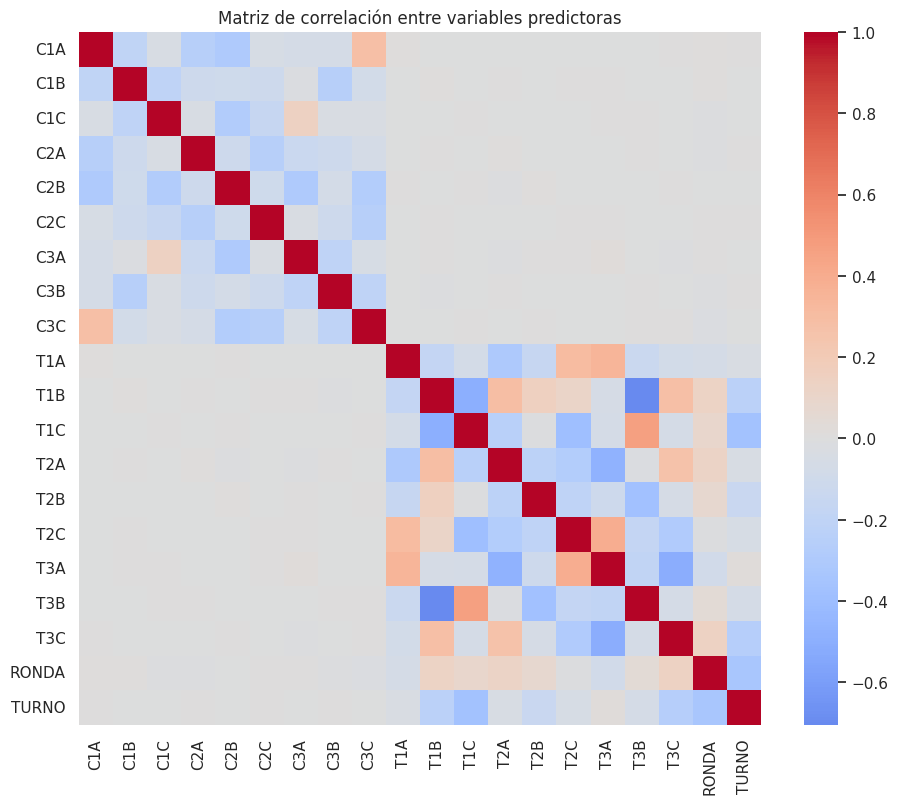

,var_1,var_2,correlacion
1,T1B,T3B,-0.705
2,T3A,T3C,-0.510
0,T1B,T1C,-0.501


In [43]:
feature_cols = [c for c in df.columns if c != "PUNTAJE"]

plt.figure(figsize=(11, 9))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables predictoras")
plt.show()

# Pares con correlación fuerte (|r| > 0.5)
pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        a, b = feature_cols[i], feature_cols[j]
        v = corr.loc[a, b]
        if abs(v) > 0.5:
            pairs.append((a, b, round(v, 3)))

pd.DataFrame(pairs, columns=["var_1", "var_2", "correlacion"]).sort_values(
    "correlacion", key=abs, ascending=False
)


### 1.7 Correlación de cada variable con `PUNTAJE`

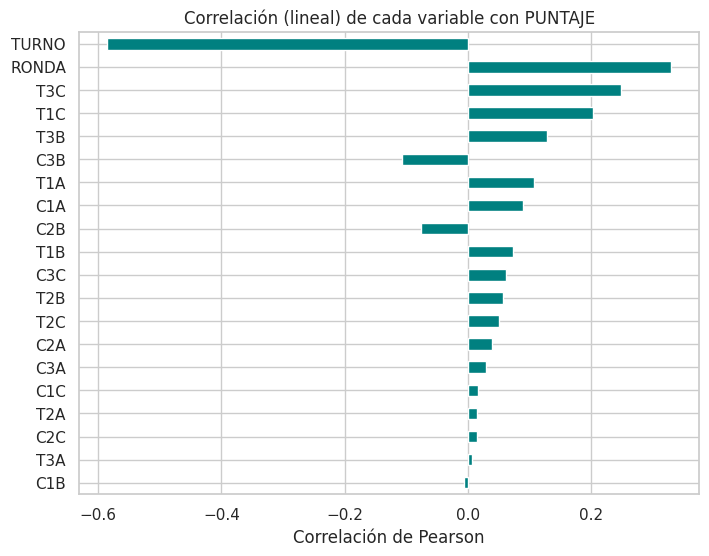

,PUNTAJE
TURNO,-0.585241
RONDA,0.329162
T3C,0.248780
T1C,0.202750
T3B,0.128320
C3B,-0.107475
T1A,0.106519
C1A,0.089565
C2B,-0.075589
T1B,0.073183


In [44]:
target_corr = df.corr(numeric_only=True)["PUNTAJE"].drop("PUNTAJE").sort_values(
    key=abs, ascending=False
)

plt.figure(figsize=(8, 6))
target_corr.plot(kind="barh", color="teal")
plt.title("Correlación (lineal) de cada variable con PUNTAJE")
plt.xlabel("Correlación de Pearson")
plt.gca().invert_yaxis()
plt.show()

target_corr


## 2. Preprocesamiento de los datos

Puntos aplicados en base al análisis previo:

- No hay valores faltantes ni duplicados que limpiar.
- No se escalan las variables porque Random Forest y XGBoost son invariantes a la escala
  de las features.
- No se eliminan variables por colinealidad (los modelos de árboles la toleran bien).
- **Split estratificado por `RONDA`**, para asegurar que train y test mantengan la misma
  proporción de partidas en cada ronda (incluidas las rondas 4 y 5, poco representadas).


In [45]:
X = df[feature_cols].copy()
y = df["PUNTAJE"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["RONDA"],   # estratificación por RONDA para mantener el balance
)

print("Train:", X_train.shape, " Test:", X_test.shape)

print("\nProporción de RONDA en el dataset completo:")
print(df["RONDA"].value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en train:")
print(df.loc[X_train.index, "RONDA"].value_counts(normalize=True).sort_index())

print("\nProporción de RONDA en test:")
print(df.loc[X_test.index, "RONDA"].value_counts(normalize=True).sort_index())


Train: (2325, 20)  Test: (582, 20)

Proporción de RONDA en el dataset completo:
RONDA
1    0.214654
2    0.392501
3    0.209494
4    0.128655
5    0.054696
Name: proportion, dtype: float64

Proporción de RONDA en train:
RONDA
1    0.214624
2    0.392688
3    0.209462
4    0.128602
5    0.054624
Name: proportion, dtype: float64

Proporción de RONDA en test:
RONDA
1    0.214777
2    0.391753
3    0.209622
4    0.128866
5    0.054983
Name: proportion, dtype: float64


Para la validación cruzada durante el entrenamiento se usa `KFold` estándar (no
estratificado, ya que la estratificación de sklearn para CV está pensada para
clasificación); el split train/test ya garantiza la representatividad de `RONDA`, y en
la sección de tuning se usa además `cross_validate` sobre el set de entrenamiento para
tener una estimación robusta del desempeño.


In [46]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 3. Entrenamiento de los modelos

Se entrenan dos modelos base (parámetros por defecto / razonables, sin tuning todavía):

- `RandomForestRegressor`
- `XGBRegressor`

Se evalúan con validación cruzada de 5 folds sobre el set de entrenamiento, usando R²,
MAE y RMSE.


In [47]:
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
}

baseline_models = {
    "Dummy (media)": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
}

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

baseline_cv_results = {}
for name, model in baseline_models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_cv_results[name] = res
    print(f"--- {name} (CV 5-fold sobre train) ---")
    print(f"R2   : {res['test_r2'].mean():.4f} +/- {res['test_r2'].std():.4f}")
    print(f"MAE  : {-res['test_mae'].mean():.4f} +/- {res['test_mae'].std():.4f}")
    print(f"RMSE : {-res['test_rmse'].mean():.4f} +/- {res['test_rmse'].std():.4f}")

cv_results = {}

for name, model in models.items():
    res = cross_validate(
        model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results[name] = res
    print(f"--- {name} (CV 5-fold sobre train) ---")
    print(f"R2   : {res['test_r2'].mean():.4f} +/- {res['test_r2'].std():.4f}")
    print(f"MAE  : {-res['test_mae'].mean():.4f} +/- {res['test_mae'].std():.4f}")
    print(f"RMSE : {-res['test_rmse'].mean():.4f} +/- {res['test_rmse'].std():.4f}")


--- Dummy (media) (CV 5-fold sobre train) ---
R2   : -0.0031 +/- 0.0036
MAE  : 3.6380 +/- 0.0329
RMSE : 4.4322 +/- 0.0383
--- LinearRegression (CV 5-fold sobre train) ---
R2   : 0.4659 +/- 0.0199
MAE  : 2.6023 +/- 0.0762
RMSE : 3.2337 +/- 0.0782
--- RandomForest (CV 5-fold sobre train) ---
R2   : 0.7254 +/- 0.0197
MAE  : 1.8271 +/- 0.0739
RMSE : 2.3172 +/- 0.0792
--- XGBoost (CV 5-fold sobre train) ---
R2   : 0.8938 +/- 0.0080
MAE  : 1.0738 +/- 0.0367
RMSE : 1.4411 +/- 0.0485


In [48]:
# Entrenamiento final de cada modelo base sobre todo el set de entrenamiento
fitted_baselines = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    fitted_baselines[name] = model

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model


## 4. Comparación de métricas para escoger el mejor modelo

Se evalúa cada modelo sobre el set de **test** (datos no vistos durante el entrenamiento
ni la validación cruzada) y se comparan R², MAE y RMSE.


In [49]:
def evaluate(model, X_te, y_te):
    preds = model.predict(X_te)
    return {
        "R2": r2_score(y_te, preds),
        "MAE": mean_absolute_error(y_te, preds),
        "RMSE": mean_squared_error(y_te, preds) ** 0.5,
    }

baseline_test_metrics = {
    name: evaluate(model, X_test, y_test) for name, model in fitted_baselines.items()
}

test_metrics = {
    name: evaluate(model, X_test, y_test) for name, model in fitted_models.items()
}

metrics_df = pd.DataFrame(test_metrics).T

full_metrics_df = pd.concat(
    [pd.DataFrame(baseline_test_metrics).T, metrics_df], axis=0
)
full_metrics_df


,R2,MAE,RMSE
Dummy (media),-0.000171,3.681179,4.468325
LinearRegression,0.437099,2.716608,3.352153
RandomForest,0.738201,1.792027,2.286081
XGBoost,0.915744,0.945698,1.296903


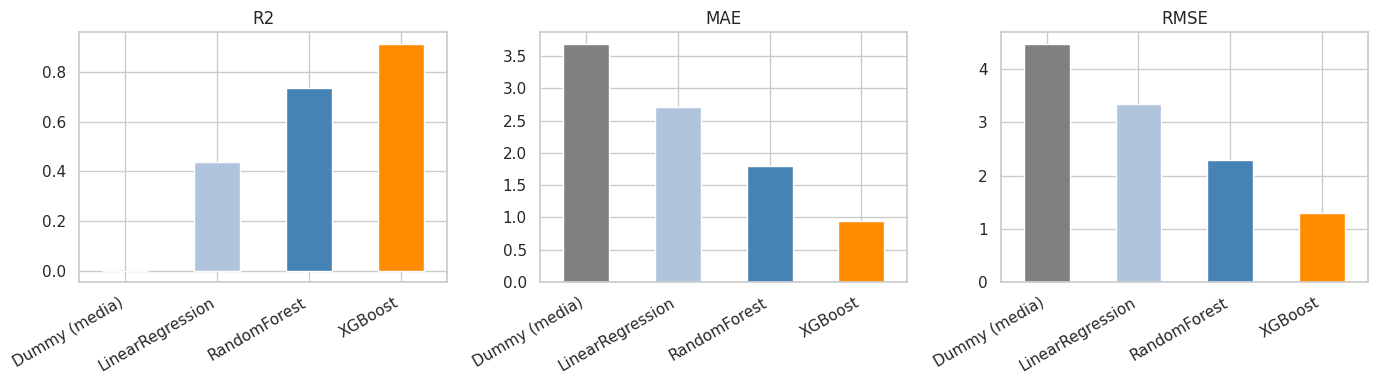

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ["gray", "lightsteelblue", "steelblue", "darkorange"]  # Dummy, Linear, RF, XGBoost

for ax, metric in zip(axes, ["R2", "MAE", "RMSE"]):
    full_metrics_df[metric].plot(kind="bar", ax=ax, color=colors)
    ax.set_title(metric)
    ax.set_xticklabels(full_metrics_df.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()


### Predicho vs. real (ambos modelos)


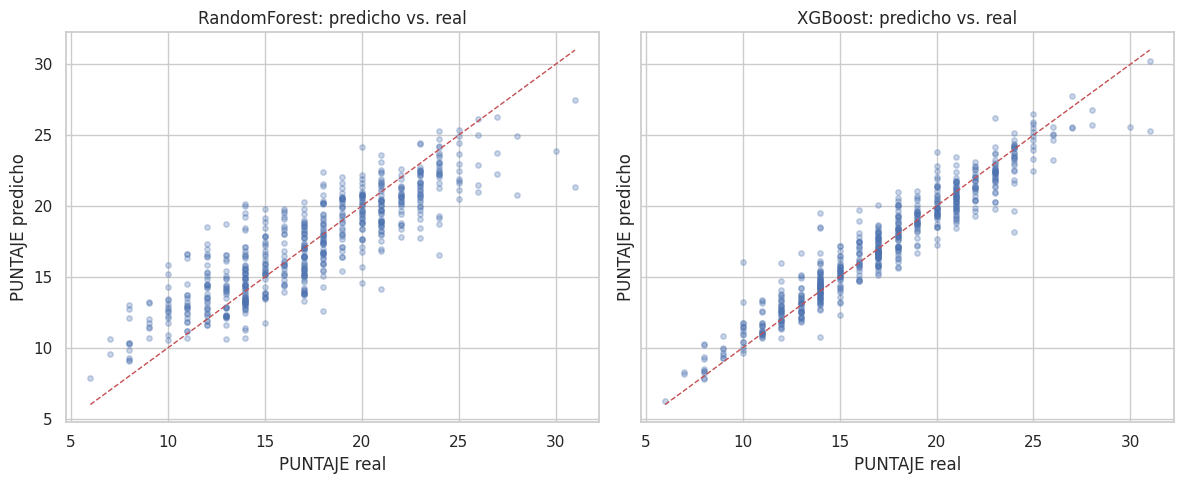

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, fitted_models.items()):
    preds = model.predict(X_test)
    ax.scatter(y_test, preds, alpha=0.3, s=15)
    lims = [y.min(), y.max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(f"{name}: predicho vs. real")
    ax.set_xlabel("PUNTAJE real")
    ax.set_ylabel("PUNTAJE predicho")
plt.tight_layout()
plt.show()


### Importancia de variables (modelos base)

Recordar que, por la multicolinealidad documentada en el EDA entre algunas variables
`T*`, el reparto de importancia entre variables correlacionadas puede ser algo
arbitrario; se interpreta a nivel de grupos de variables más que de una sola celda.


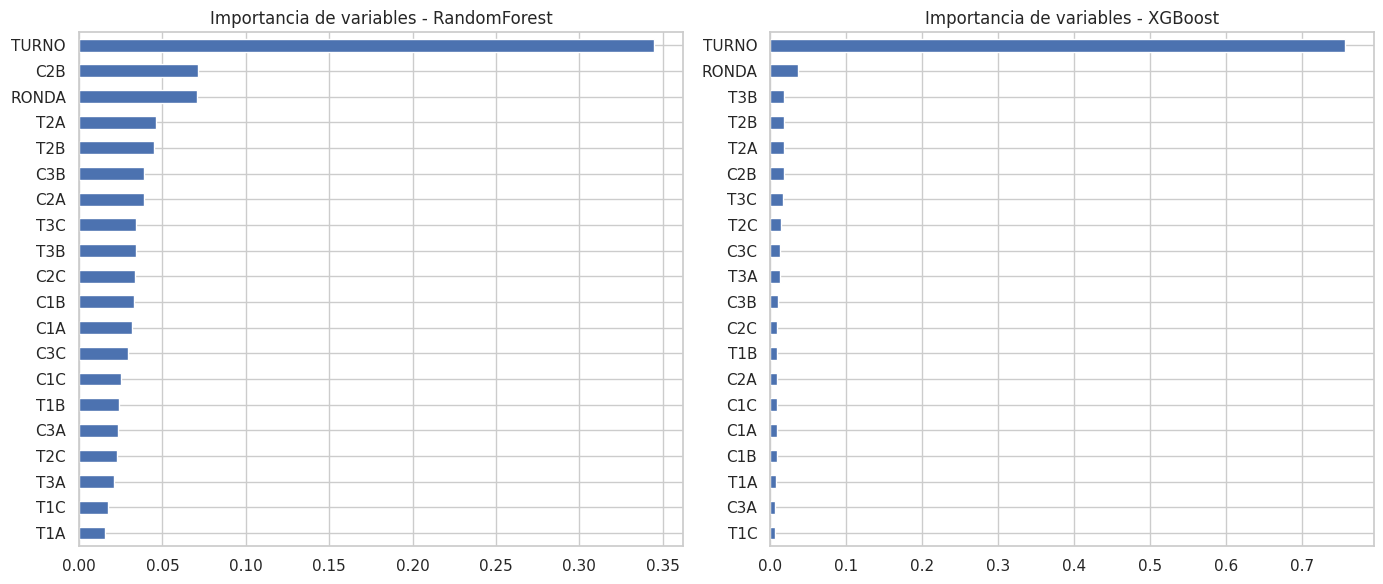

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, model) in zip(axes, fitted_models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances.sort_values(ascending=True).plot(kind="barh", ax=ax)
    ax.set_title(f"Importancia de variables - {name}")
plt.tight_layout()
plt.show()


In [53]:
best_model_name = metrics_df["R2"].idxmax()
print(f"Modelo ganador según R2 en test: {best_model_name}")
metrics_df.loc[[best_model_name]]


Modelo ganador según R2 en test: XGBoost


,R2,MAE,RMSE
XGBoost,0.915744,0.945698,1.296903


## 5. Tuning del modelo ganador

Se realiza una búsqueda de hiperparámetros con `RandomizedSearchCV` (más eficiente que un
`GridSearchCV` exhaustivo dado el tamaño del espacio de búsqueda), usando `KFold` de 5
particiones sobre el set de entrenamiento y R² como métrica objetivo.

**Nota:** la celda de abajo asume que el ganador fue `XGBoost` (resultado típico según el
baseline del análisis previo). Si en tu ejecución el ganador es `RandomForest`, usa la
grilla alternativa que se deja comentada.


In [54]:
if best_model_name == "XGBoost":
    param_distributions = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
        "reg_alpha": [0, 0.01, 0.1, 1],
        "reg_lambda": [1, 1.5, 2, 5],
    }
    base_estimator = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
else:
    param_distributions = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.5, None],
    }
    base_estimator = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="r2",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print("Mejor R2 en CV:", search.best_score_)
print("Mejores hiperparámetros:")
search.best_params_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejor R2 en CV: 0.9348766684532166
Mejores hiperparámetros:


{'subsample': 0.8,
 'reg_lambda': 5,
 'reg_alpha': 0,
 'n_estimators': 800,
 'min_child_weight': 5,
 'max_depth': 4,
 'learning_rate': 0.2,
 'colsample_bytree': 1.0}

In [55]:
tuned_model = search.best_estimator_
tuned_metrics = evaluate(tuned_model, X_test, y_test)

print(f"Métricas del modelo {best_model_name} tuneado (test):")
for metric_name, value in tuned_metrics.items():
    print(f"  {metric_name:5s}: {value:.4f}")


Métricas del modelo XGBoost tuneado (test):
  R2   : 0.9505
  MAE  : 0.7001
  RMSE : 0.9943


In [56]:
comparison = pd.DataFrame(
    {
        f"{best_model_name} (base)": test_metrics[best_model_name],
        f"{best_model_name} (tuned)": tuned_metrics,
    }
).T

# Variación porcentual del modelo tuneado respecto al base para cada métrica
comparison["R2_delta"] = comparison["R2"] - comparison["R2"].iloc[0]
comparison["MAE_delta_%"] = (
    (comparison["MAE"] - comparison["MAE"].iloc[0]) / comparison["MAE"].iloc[0] * 100
)
comparison["RMSE_delta_%"] = (
    (comparison["RMSE"] - comparison["RMSE"].iloc[0]) / comparison["RMSE"].iloc[0] * 100
)

comparison


,R2,MAE,RMSE,R2_delta,MAE_delta_%,RMSE_delta_%
XGBoost (base),0.915744,0.945698,1.296903,0.000000,0.000000,0.00000
XGBoost (tuned),0.950474,0.700066,0.994319,0.034729,-25.973555,-23.33127


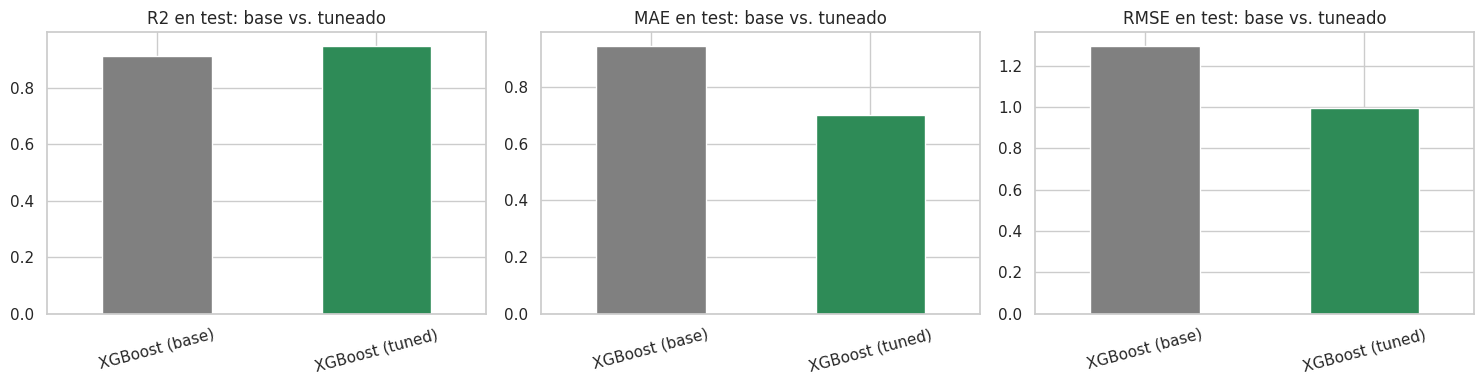

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["R2", "MAE", "RMSE"]):
    comparison[metric].plot(kind="bar", ax=ax, color=["gray", "seagreen"])
    ax.set_title(f"{metric} en test: base vs. tuneado")
    ax.set_xticklabels(comparison.index, rotation=15)
plt.tight_layout()
plt.show()


### Importancia de variables del modelo final


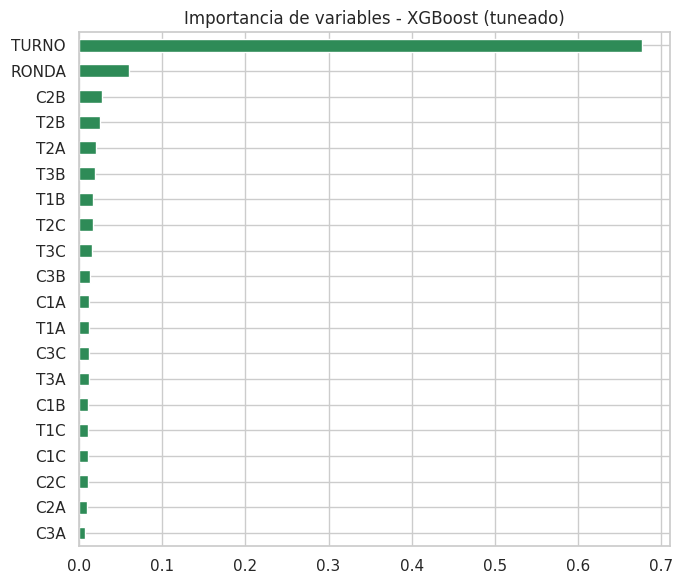

In [58]:
final_importances = pd.Series(
    tuned_model.feature_importances_, index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(7, 6))
final_importances.plot(kind="barh", color="seagreen")
plt.title(f"Importancia de variables - {best_model_name} (tuneado)")
plt.tight_layout()
plt.show()


### Conclusiones

- El modelo ganador y sus métricas finales quedan resumidos en la tabla de la sección 4
  (`metrics_df`) y en la comparación base vs. tuneado de esta sección (`comparison`).
- Si el R² del modelo tuneado es muy cercano a 1, esto refuerza la hipótesis planteada en
  el EDA de que `PUNTAJE` tiene un fuerte componente determinístico calculable a partir
  del estado del tablero y la carta jugada, más que una relación ruidosa que dependa de
  factores no observados.
- Antes de llevar el modelo a producción, se recomienda:
  1. Repetir esta evaluación con más partidas simuladas, en particular de rondas 4 y 5,
     para confirmar que el desempeño se mantiene en esa región poco representada.
  2. Guardar el modelo final (`tuned_model`) y los hiperparámetros usados para
     reproducibilidad.


In [59]:
# Guardar el modelo final (opcional)
import joblib
joblib.dump(tuned_model, "modelo_final.pkl")
print("Modelo guardado en modelo_final.pkl")


Modelo guardado en modelo_final.pkl


## 6. Interpretabilidad con SHAP (modelo tuneado)

`feature_importances_` reparte el crédito de forma algo arbitraria cuando hay variables
correlacionadas (recordar la multicolinealidad documentada entre las variables `T*` en
el EDA). SHAP (SHapley Additive exPlanations) da una explicación más consistente:

- Es **aditivo**: la suma de los SHAP values de una fila más el valor base reconstruye
  exactamente la predicción del modelo para esa fila.
- Muestra **dirección** del efecto (si un valor alto de la variable empuja `PUNTAJE`
  hacia arriba o hacia abajo), no solo cuánto "importa" en promedio.
- Permite explicaciones tanto **globales** (todo el dataset) como **locales** (una
  jugada puntual).

Se usa `TreeExplainer`, que es exacto y eficiente para modelos basados en árboles como
Random Forest y XGBoost.


In [60]:
# Si no está instalado: !pip install shap --quiet
import shap

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer(X_test)

print("Shape de shap_values.values:", shap_values.values.shape)


Shape de shap_values.values: (582, 20)


### 6.1 Importancia global de variables (SHAP summary plot - barras)

Promedio del valor absoluto de SHAP por variable: análogo a `feature_importances_`, pero
calculado de forma más consistente ante variables correlacionadas.


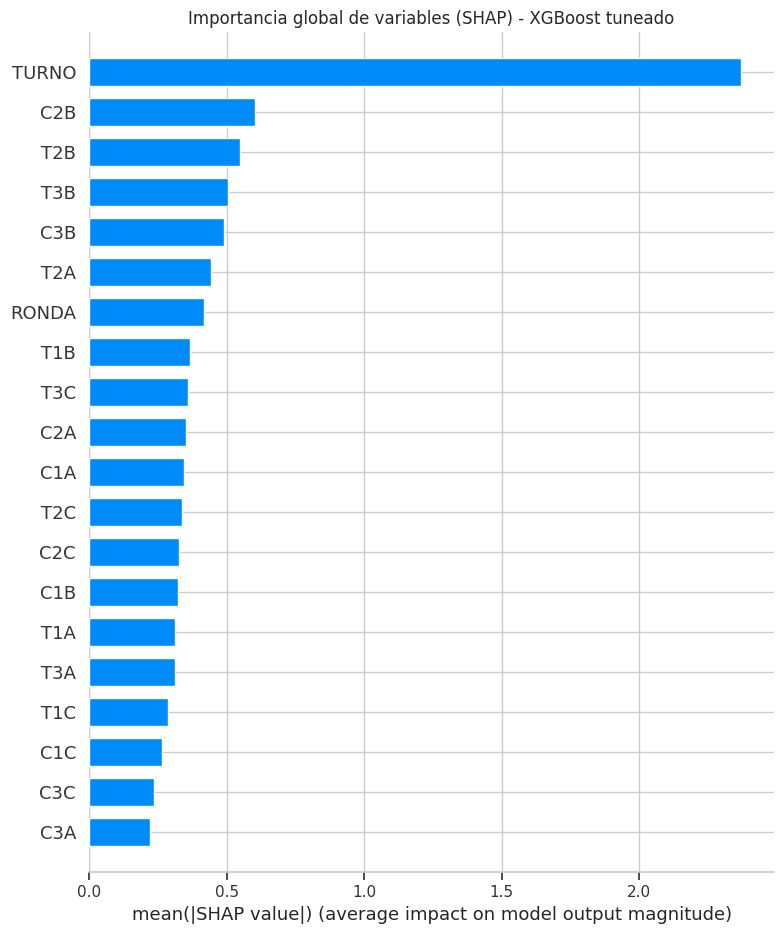

In [61]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title(f"Importancia global de variables (SHAP) - {best_model_name} tuneado")
plt.tight_layout()
plt.show()


### 6.2 Distribución e impacto por variable (SHAP summary plot - beeswarm)

Cada punto es una fila del set de test. La posición en el eje X indica si esa variable
empujó la predicción de `PUNTAJE` hacia arriba o hacia abajo para esa fila, y el color
indica si el valor de la variable era alto (rojo) o bajo (azul).


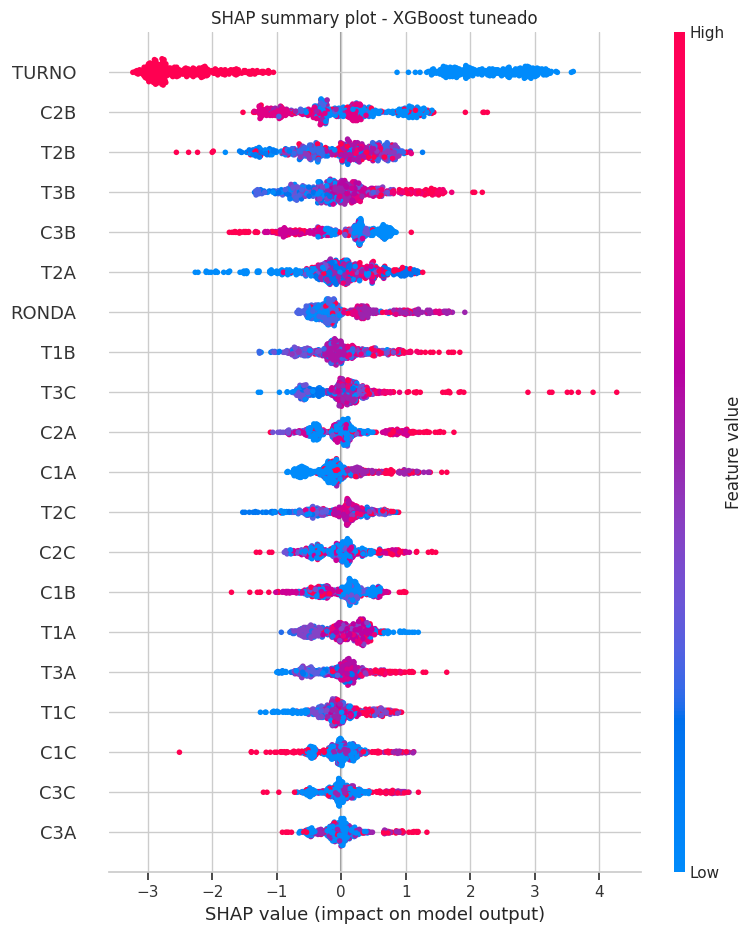

In [62]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title(f"SHAP summary plot - {best_model_name} tuneado")
plt.tight_layout()
plt.show()


### 6.3 Dependence plots de las variables más importantes

Se inspeccionan con más detalle las variables que resultaron más influyentes en el
análisis previo (`TURNO`, `C2B`, `RONDA`), viendo cómo el SHAP value de cada una varía
según su propio valor y, opcionalmente, coloreado por una segunda variable con la que
pueda interactuar.


Top 3 variables según SHAP: ['TURNO', 'C2B', 'T2B']


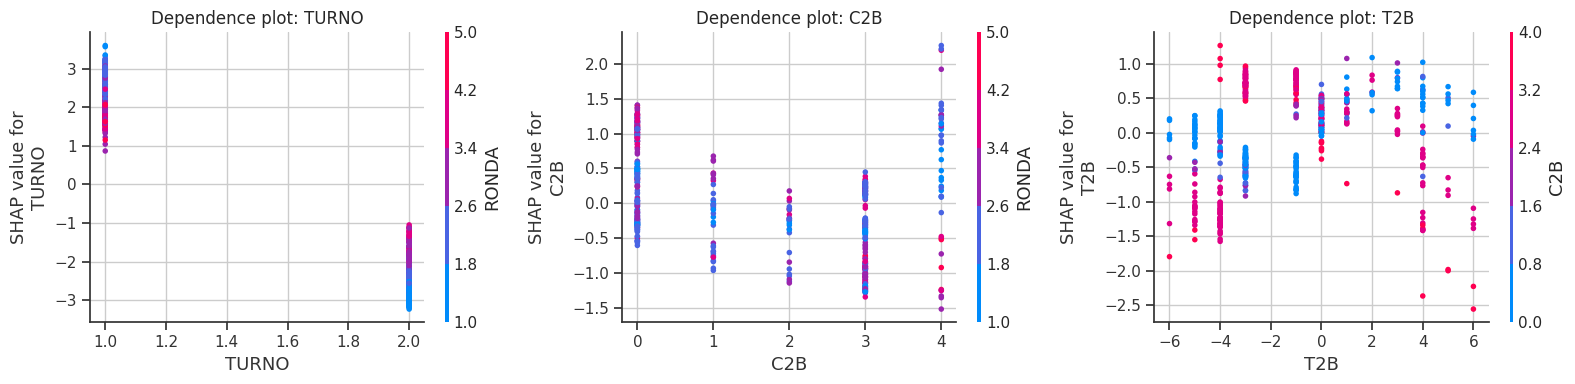

In [63]:
top_features = (
    pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols)
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
print("Top 3 variables según SHAP:", top_features)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top_features):
    shap.dependence_plot(feat, shap_values.values, X_test, ax=ax, show=False)
    ax.set_title(f"Dependence plot: {feat}")
plt.tight_layout()
plt.show()


### 6.4 Explicación local de un caso puntual

Ejemplo de cómo SHAP explica la predicción de una jugada individual del set de test:
qué variables la empujaron por encima o por debajo del valor base (`PUNTAJE` promedio).


PUNTAJE real: 11
PUNTAJE predicho: 11.22


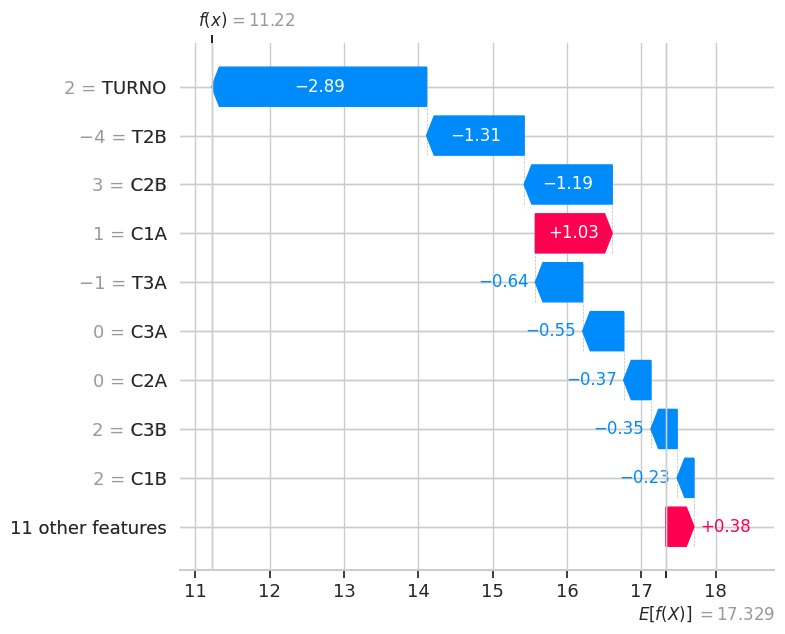

In [64]:
idx = 0  # cambiar el índice para inspeccionar otra jugada del set de test
print(f"PUNTAJE real: {y_test.iloc[idx]}")
print(f"PUNTAJE predicho: {tuned_model.predict(X_test.iloc[[idx]])[0]:.2f}")

shap.plots.waterfall(shap_values[idx], show=False)
plt.tight_layout()
plt.show()


### Conclusiones de la sección SHAP

- Comparar el orden de variables del *summary plot* de SHAP contra el gráfico de
  `feature_importances_` de la sección 4/5: si el orden es similar, refuerza la confianza
  en que `TURNO`, `C2B` y `RONDA` (u otras que aparezcan) son realmente las variables más
  influyentes y no un artefacto de la colinealidad entre las `T*`.
- Los *dependence plots* ayudan a confirmar hipótesis del dominio del juego (por ejemplo,
  si `TURNO=2` sistemáticamente reduce `PUNTAJE` porque hay menos margen para ocupar
  posiciones nuevas al ser el segundo jugador en mover).
- Para reportes o presentaciones a stakeholders no técnicos, el *waterfall plot* de un
  caso puntual suele ser más fácil de comunicar que una tabla de importancia global.
